<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Lan%C3%A7amentos_Vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas Phyton

In [1]:
!pip install requests

In [130]:
!pip install unidecode

In [131]:
!pip install fuzzywuzzy

In [4]:
#Carrega Bibliotecas
import pandas as pd
import numpy as np
import re
from functools import lru_cache
from unidecode import unidecode
import requests
from collections import defaultdict
from fuzzywuzzy import fuzz
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import plotly.express as px


/usr/local/lib/python3.12/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


# Fazer Upload planilhas
1.   Lançamentos
2.   Inci
3.   Vendas

In [5]:
#Lançamentos
from google.colab import files
uploaded = files.upload()

Saving Brasil, 30-09-25.xlsx to Brasil, 30-09-25.xlsx


In [6]:
filename = next(iter(uploaded))

In [7]:
# INCI name produtos
from google.colab import files
inci = files.upload()

Saving inci_16_08.xlsx to inci_16_08.xlsx


In [8]:
filename2 = next(iter(inci))

In [9]:
#Vendas Distribuidores
from google.colab import files
dist = files.upload()

Saving sales.xlsx to sales.xlsx


In [10]:
filename4 = next(iter(dist))

#Funções

In [132]:
#ANalise de Vendas
def limpar(texto):
    if pd.isnull(texto):
        return []
    texto = unidecode(str(texto)).lower()
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[.,/\\-]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return [p for p in texto.split(' ') if p]

def extrair_chave(palavras):
    relevantes = [p for p in palavras if p not in PALAVRAS_IRRELEVANTES]
    if not relevantes:
        relevantes = palavras
    if not relevantes:
        return ''
    for p in relevantes:
        if len(p) > 1:
            return p
    return ' '.join(relevantes[:3])


def gerar_chaves(df, coluna1, coluna2=None, coluna3=None):
    palavras1 = df[coluna1].apply(limpar)
    palavras2 = df[coluna2].apply(limpar) if coluna2 else pd.Series([[]] * len(df))
    palavras3 = df[coluna3].apply(limpar) if coluna3 else pd.Series([[]] * len(df))

    def chave_final(idx):
        for lista in [palavras1.iloc[idx], palavras2.iloc[idx], palavras3.iloc[idx]]:
            chave = extrair_chave(lista)
            if chave:
                return chave
        return f"sem_chave_{idx}"  # fallback seguro

    return pd.Series([chave_final(i) for i in range(len(df))], index=df.index)


In [133]:
def formatar_material(coluna):
    def extrair_codigo(texto):
        #Tenta extrair o padrão: 2+ letras + 1+ números
        match = re.search(r'\b([A-Za-z]{2,}\s*\d{1,})\b', texto)
        if match:
            return match.group(1).upper().strip()
    return coluna.apply(extrair_codigo)

In [134]:
#this checks if any combination of INCI as present in Ingredient
def verifica_ingrediente(formula,produto,material):
  quantidade = len(produto.difference(formula))
  if quantidade == 0:
    return material
  return None

In [135]:
#If last code is true, this returns the Descrição name
def procura_produtos(formula, produtos, materiais):
  formula = formula.copy()
  resultados = []
  for prod, mat in zip(produtos, materiais):
    resultado = verifica_ingrediente(formula, prod, mat)
    if resultado is not None:
      formula = formula.difference(prod) ## Para remover os ingredientes já encontrados numa nova busca.
      resultados.append(resultado)
  return resultados

In [136]:
# Função para sinalizar ingredientes do dictOTHERS
def sinaliza_ingredientes(x):
    ingredientes = set().union(*x)  # une todos os sets/listas de ingredientes do grupo
    encontrados = set()
    for ing in ingredientes:
        for palavra in dictOTHERS:
            if palavra.lower() in ing.lower():
                encontrados.add(ing)
    return ', '.join(sorted(encontrados))

In [137]:
#this code transpose data. Used when we bring each category and the number of lauches.
def transpor (df, coluna, linha):
  for cat in df[coluna].unique():
    f = df[coluna] == cat
    df[cat] = df[f][linha]
    f = df[cat].isna()
    df.loc[f, cat] = df.loc[f, cat].apply(lambda x:[])

In [147]:

def to_set(x):
    s = set()
    for item in x:
        if isinstance(item, list):
            s.update(item)
        elif isinstance(item, str):
            s.add(item)
    return list(s)  # Retorna lista para compatibilidade com Excel


In [148]:
def transpor_2 (df, coluna, linha):
  for cat in df[coluna].unique():
    f = df[coluna] == cat
    df[cat] = df[f][linha]
    f = df[cat].isna()
    df.loc[f, cat] = df.loc[f, cat].apply(lambda x:x)

In [149]:
def extrair_estado(texto):
    if pd.isnull(texto):
        return None
    texto = str(texto).strip().lower()
    # Procura por sigla
    for sigla in estados:
        if re.search(r'\b' + re.escape(sigla.lower()) + r'\b', texto):
            return sigla
    # Procura por nome do estado
    for nome, sigla in estados_nome_para_sigla.items():
        if nome in texto:
            return sigla
    return None

In [150]:

# Função para extrair ingredientes exclusivos por subcategoria
def ingredientes_exclusivos_por_categoria(df, categoria, coluna_ingredientes):
    df_cat = df[df['Categoria'].str.contains(categoria, case=False, na=False)]
    subcats = df_cat['Sub-Categoria'].dropna().unique()
    subcat_ingredientes = {}

    for subcat in subcats:
        formulas = df_cat[df_cat['Sub-Categoria'] == subcat][coluna_ingredientes].dropna()
        sets_ingredientes = [set(map(str.strip, ing.split(','))) for ing in formulas]
        comuns = set.intersection(*sets_ingredientes) if sets_ingredientes else set()
        todos = set().union(*sets_ingredientes)
        exclusivos = todos - comuns
        subcat_ingredientes[subcat] = exclusivos

    # Agrupa todos os exclusivos da categoria
    ingredientes_filtrados = set().union(*subcat_ingredientes.values())
    return ingredientes_filtrados

# Função para remover pigmentos (para Maquilagem)
def remover_pigmentos(ingredientes):
    pigmentos = ['mica', 'talc', 'titanium dioxide']
    return [ing for ing in ingredientes if not (
        'ci' in ing.lower() or
        any(pig in ing.lower() for pig in pigmentos)
    )]

# Função para gerar nuvem de palavras
def gerar_nuvem(ingredientes, categoria):
    texto = ', '.join(ingredientes)
    wordcloud = WordCloud(width=1000, height=600, background_color='white').generate(texto)
    plt.figure(figsize=(12, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nuvem de Palavras - Ingredientes INCI exclusivos ({categoria})', fontsize=16)
    plt.savefig(f"nuvem_INCI_exclusivos_{categoria.lower()}.png")
    plt.show()


#Dicionarios

In [151]:
#Dicionários
PALAVRAS_IRRELEVANTES = {
    'industria', 'comercio', 'cosmetico', 'cosmeticos', 'tecnologia', 'ltda', 'me', 'eireli', 'sa', 'cia', 'comercial',
    'produtos', 'servicos', 'serviço', 'do', 'da', 'de', 'dos', 'das', 'the', 'group', 'grupo',
    'inc', 'corp', 'corporation', 'associados', 'associado', 'associacao', 'associação', 'holding', 'importadora',
    'exportadora', 'importacao', 'importação', 'exportacao', 'exportação', 'distribuidora', 'distribuidor', 'fabricacao',
    'fabricante', 'comerciante', 'comercio', 'comércio', 'comercial', 'empresa', 'sociedade', 'unipessoal'
}


In [152]:
# Dicionário de siglas e nomes de estados
estados = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas', 'BA': 'Bahia', 'CE': 'Ceará',
    'DF': 'Distrito Federal', 'ES': 'Espírito Santo', 'GO': 'Goiás', 'MA': 'Maranhão', 'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná',
    'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina',
    'SP': 'São Paulo', 'SE': 'Sergipe', 'TO': 'Tocantins'
}
# Inverte para buscar por nome também
estados_nome_para_sigla = {v.lower(): k for k, v in estados.items()}


In [153]:
#Dicionário Silicones geral
dictOTHERS = {'methicone':'1', 'Dimethicone':'1','methicone Crosspolymer':'1','methiconol':'1',
              'ylsiloxysilicate':'1', 'ylsilsesquioxane':'1', 'Disiloxane':'1', 'Silica':'1','siloxane':'1'}

# Análise Ferramenta de Vendas

In [154]:
data = '/content/'+filename4
df_sale = pd.read_excel(data)
pd.options.display.max_columns=None
df_sale.nunique()

,0
Distributor (subsidiary),4
WACKER Material No.,63
WACKER Material Name,92
Customer Name,649
Region (State/Province) ship-to (of customer),22
Month of Invoice,9
Quantity actual period,148


In [155]:
# Prepara Relatório

df_sale = df_sale[df_sale['WACKER Material Name'].str.contains('BELSIL', case=False, na=False)]

# Limpa e padroniza a coluna 'Material'
df_sale['WACKER Material Name'] = formatar_material(df_sale['WACKER Material Name'].astype(str))

# Padroniza fabricantes e distribuidores
df_sale['KeyManuf'] = gerar_chaves(df_sale, 'Customer Name')
df_sale['Estado'] = df_sale['Region (State/Province) ship-to (of customer)']
df_sale['Distributor (subsidiary)'] = df_sale['Distributor (subsidiary)'].astype(str)


# Gera os resumos por ano
df_final = df_sale.groupby(['KeyManuf', 'Estado']).agg(
               Distributor_Set = ('Distributor (subsidiary)', lambda x: sorted({str(i).strip() for i in x if pd.notnull(i)})),
               Sales_Qnty_2025 = ('WACKER Material Name', lambda x: len({str(i).strip() for i in x if pd.notnull(i)})),
               Sales_Kg_2025 = ('Quantity actual period', 'sum'),
               Sales_2025 = ('WACKER Material Name', to_set),
               )

# Salva o resultado em Excel
df_final.to_excel('Resumo_vendas.xlsx')
df_final.head()

,,Distributor_Set,Sales_Qnty_2025,Sales_Kg_2025,Sales_2025
KeyManuf,Estado,,,,
&co,SP,[FOCUS QUIMICA],3,398.0,"[TMS 803, DM 5, EG 6000]"
a&s,SP,[FOCUS QUIMICA],4,3814.0,"[OW 2100, DM 0, TMS 803, DM 6010]"
abalo,SP,[FOCUS QUIMICA],6,60.0,"[OW 2100, GB 3025, ADM 9000, GB 3024, DM 350, ..."
abboccato,SC,[FOCUS QUIMICA],1,5.0,[DM 6010]
abs,BA,[MORAIS DE CASTRO],1,38.0,[GB 150]


# Análise Relatórios Lançamentos

In [156]:
#Carrega o banco de dados como tabela
data = '/content/'+filename
df_launches = pd.read_excel(data)
pd.options.display.max_columns = None
df_launches.nunique()

,0
Número do Produto,6220
Data de Publicação,430
Produto,3741
Marca,3495
Empresa,908
Categoria,4
Sub-Categoria,39
Descrição do Produto,6219
Preço por 100g/ml,3218
Preço em moeda local,1333


In [157]:
#Edita Coluna Ano
df_launches['Ano'] = pd.to_datetime(df_launches['Data de Publicação']).dt.year

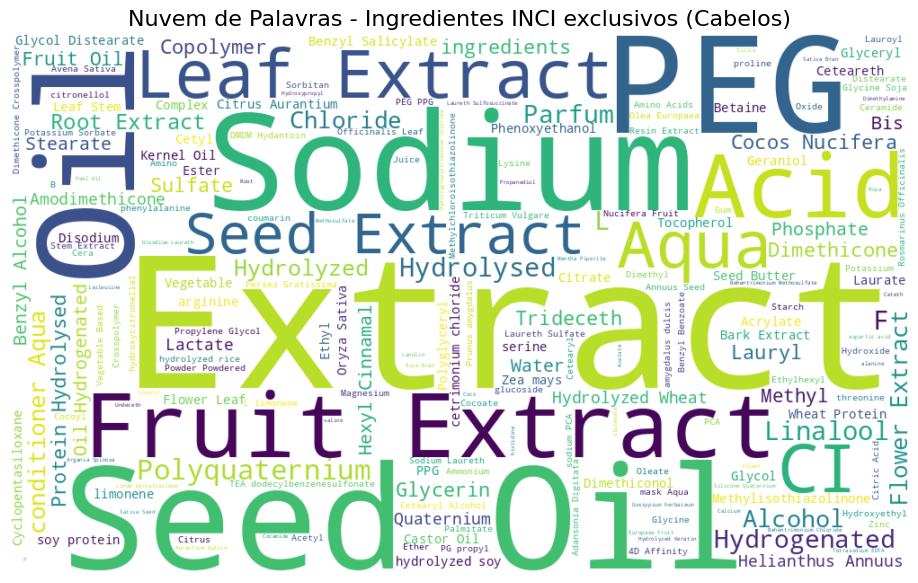

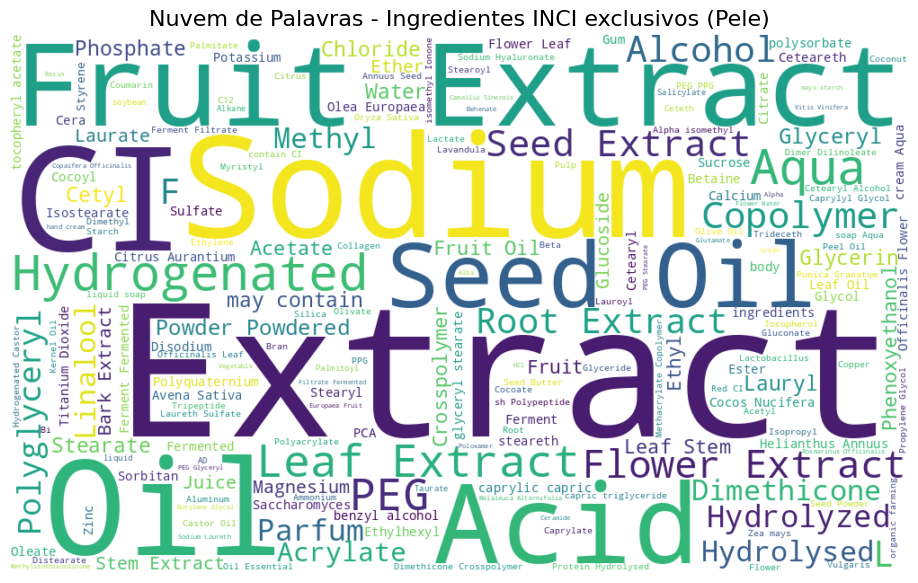

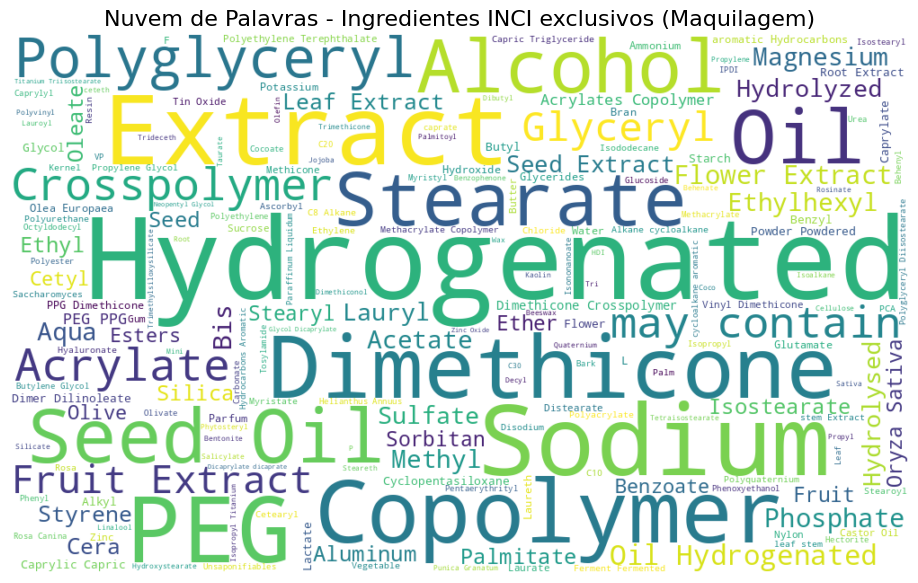

In [158]:
# Gera nuvens para as categorias, apenas para todos os ingrendientes.

# Defina a coluna de referência
coluna_ref = "Ingredients (Standard form)"  # Altere aqui se necessário

# Gera nuvens para as categorias
gerar_nuvem(ingredientes_exclusivos_por_categoria(df_launches, "Cabelos", coluna_ref), "Cabelos")
gerar_nuvem(ingredientes_exclusivos_por_categoria(df_launches, "Pele", coluna_ref), "Pele")
ingredientes_maquiagem = ingredientes_exclusivos_por_categoria(df_launches, "Maquilagem", coluna_ref)
ingredientes_maquiagem_filtrados = remover_pigmentos(ingredientes_maquiagem)
gerar_nuvem(ingredientes_maquiagem_filtrados, "Maquilagem")

##Upload INCI

In [159]:
data = '/content/'+filename2
df_inci = pd.read_excel(data)
pd.options.display.max_columns=None
df_inci.nunique()

,0
Produto,51
Ingrediente,50
Prioridade,3


## Contém Silicone?

In [160]:
pattern = '|'.join(map(re.escape, dictOTHERS.keys()))
df_launches['Silicone'] = df_launches['Ingredients (Standard form)'].str.extract(f'({pattern})', expand=False)
df_launches['Silicone'] = df_launches['Silicone'].map(dictOTHERS).fillna(0)


## Gera chave de Material


In [161]:
#Edita tabela INCI

df_inci.dropna(inplace=True)
df_inci['Produto'] = formatar_material(df_inci['Produto'])

#Cria uma lista iterável dos ingredientes nos Produtos
df_inci['Ing'] = df_inci['Ingrediente'].str.split(', ').apply(set)
df_inci.sort_values('Prioridade', ascending=True, inplace=True)

In [162]:
#Dicionário de palavras a remover da coluna Ingredientes no Mintel
dictIng = {
    r'\s*and/or\s*': ',',
    r',\s*': ',',
    r'\s*,': ',',
    r'\s*\(and\)\s*': ','
}

In [163]:
# Cria coluna com produtos identificados
df_launches['Ingredients (Standard form)'] = df_launches['Ingredients (Standard form)'].astype(str)
#Cria uma lista iterável das ingredientes cosmeticos
df_launches['Ing'] = (
    df_launches['Ingredients (Standard form)']
    .replace(dictIng, regex=True)
    .str.split(',')
    .apply(set)
)

# Relaciona os ingredientes cosméticos
df_launches['Prod Ident'] = df_launches['Ing'].apply(
    lambda formulacao: procura_produtos(formulacao, df_inci['Ing'], df_inci['Produto'])
)

## Gera Chave Fabricante



In [164]:
df_launches['Fabricante']= df_launches['Fabricante'].astype(str)
df_launches['Marca']= df_launches['Marca'].astype(str)
df_launches['Empresa']= df_launches['Empresa'].astype(str)
df_launches['Fabricante'] = df_launches['Fabricante'].fillna(df_launches['Empresa'])
df_launches['KeyManuf'] = gerar_chaves(df_launches, 'Fabricante', 'Empresa', 'Marca')
df_launches['KeyMarca'] = gerar_chaves(df_launches, 'Marca')
df_launches['KeyEmpresa'] = gerar_chaves(df_launches, 'Empresa')

Preencher os valores ausentes de 'Estado' com base em 'KeyManuf'

In [165]:
# Exemplo: supondo que sua coluna de empresa é 'Fabricante'
df_launches['Estado'] = df_launches['Manufacturer Company Address'].apply(extrair_estado)

In [166]:
# Preencher os valores ausentes de 'Estado' com base em 'KeyManuf'

missing_estado = df_launches[df_launches['Estado'].isna()]
for index, row in missing_estado.iterrows():
    keymanuf = row['KeyManuf']

    # Buscar registros com o mesmo 'KeyManuf' e 'Estado' não nulo
    estado_valido = df_launches[
        (df_launches['KeyManuf'] == keymanuf) &
        (df_launches['Estado'].notna())
    ]['Estado'].unique()

    # Se houver apenas um valor único de 'Estado', preencher
    if len(estado_valido) == 1:
        df_launches.at[index, 'Estado'] = estado_valido[0]

## Relatório de Lançamentos

In [167]:
df_launches.head()

,Número do Produto,Data de Publicação,Produto,Marca,Empresa,Categoria,Sub-Categoria,Descrição do Produto,Preço por 100g/ml,Preço em moeda local,Tipo de Lançamento,Posicionamento,Ingredients (Standard form),Fabricante,Território da empresa fabricante,Local de fabricação,Manufacturer Company Address,Link da Imagem Primária,Ano,Silicone,Ing,Prod Ident,KeyManuf,KeyMarca,KeyEmpresa,Estado
0,11306988,2024-01-02,Drying Gel,Needs Controle de Oleosidade,Instituto Pasteur de Cosmiatria,Produtos para Pele,Cuidado Facial/Pescoço,Needs Controle de Oleosidade Gel Secativo (Dry...,139.50,27.90,Nova Variedade/Extensão de Linha,"Botânico/Herbóreo, Antiacne, Testado Dermatolo...","Aqua, Alcohol, Glycerin, Propylene Glycol, Hyd...",Instituto Pasteur de Cosmiatria,Brazil,NaN,Porto Alegre - RS,https://media.mintel.com/i01/mediaserver/perfo...,2024,0,"{Glycerin, Aqua, Alcohol, Hydroxyethylcellulos...",[],instituto,needs,instituto,RS
1,11369612,2024-01-02,Shampoo,Elefunte Baby Cachos Perfeitinhos,Cham's Industria de Cosméticos,Produtos para Cabelos,Xampu,Elefunte Baby Cachos Perfeitinhos (Perfect Cur...,6.79,13.58,Novo Produto,"Bebês e Crianças (0-4), Botânico/Herbóreo, Hip...","Aqua, Sodium Laureth Sulfate, Sodium Cocoampho...",Cham's Industria de Cosméticos,Brazil,Brasil,NaN,https://media.mintel.com/i01/mediaserver/perfo...,2024,0,"{Guar Hydroxypropyltrimonium Chloride, Cocamid...",[],cham's,elefunte,cham's,None
2,11369614,2024-01-02,Conditioner,Elefunte Baby Cachos Perfeitinhos,Cham's Industria de Cosméticos,Produtos para Cabelos,Condicionador,Elefunte Baby Cachos Perfeitinhos Condicionado...,8.75,17.50,Novo Produto,"Bebês e Crianças (0-4), Fortificado com Vitami...","Aqua, Cetyl Alcohol, Stearamidopropyl Dimethyl...",Cham's Industria de Cosméticos,Brazil,Brasil,NaN,https://media.mintel.com/i01/mediaserver/perfo...,2024,1,"{Butylphenyl Methylpropional, Cetyl Alcohol, C...",[GB 1020],cham's,elefunte,cham's,None
3,11369618,2024-01-02,Conditioner,Elefunte Baby Cabelos Claros,Cham's Industria de Cosméticos,Produtos para Cabelos,Condicionador,Elefunte Baby Cabelos Claros Condicionador (Li...,8.75,17.50,Novo Produto,"Bebês e Crianças (0-4), Fortificado com Vitami...","Aqua, Cetyl Alcohol, Stearamidopropyl Dimethyl...",Cham's Industria de Cosméticos,Brazil,NaN,NaN,https://media.mintel.com/i01/mediaserver/perfo...,2024,1,"{Butylphenyl Methylpropional, Cetyl Alcohol, C...",[GB 1020],cham's,elefunte,cham's,None
4,11369620,2024-01-02,Shampoo,Elefunte Baby Hora de Dormir,Cham's Industria de Cosméticos,Produtos para Cabelos,Xampu,Elefunte Baby Hora de Dormir Shampoo is now av...,6.79,13.58,Novo Produto,"Bebês e Crianças (0-4), Botânico/Herbóreo, Hip...","Aqua, Sodium Laureth Sulfate, Sodium Cocoampho...",Cham's Industria de Cosméticos,Brazil,NaN,NaN,https://media.mintel.com/i01/mediaserver/perfo...,2024,0,"{Guar Hydroxypropyltrimonium Chloride, Cocamid...",[],cham's,elefunte,cham's,None


In [168]:
df_launches['indice']=1
transpor_2(df_launches, 'Categoria', 'indice')

In [169]:
#renomeia coluna categoria
df_launches.rename(columns={'Produtos para Pele':'Pele', 'Produtos para Cabelos':'Cabelos',
                            'Maquilagem': 'Make',
                            'Número do Produto':'Total Lançamentos'},inplace=True)

In [170]:
df_c = df_launches.groupby(['KeyManuf', 'Estado'], dropna=False)[['Pele', 'Cabelos', 'Make']].apply(lambda x:x.count())

In [171]:
#cria tabela que lista o fabricante, o estado e o total de lançamentos, quais tem silicone,
df_b = df_launches.groupby(['KeyManuf', 'Estado'], dropna=False).agg({
    'KeyMarca': to_set,
    'KeyEmpresa': to_set,
    'Total Lançamentos': 'count',
    'Silicone': 'count',
    'Prod Ident': to_set,
    'Ing': sinaliza_ingredientes
})

In [172]:
#Une tabelas anteriores
df_launches_fab = pd.concat([df_c, df_b], axis=1).reset_index()

In [173]:
df_launches_fab.to_excel('Relatório Lançamentos.xlsx')
df_launches_fab.head()

,KeyManuf,Estado,Pele,Cabelos,Make,KeyMarca,KeyEmpresa,Total Lançamentos,Silicone,Prod Ident,Ing
0,&co,SP,17,0,5,"[pharmapele, pinkcheeks, alva, bars, pink, bey...","[ollie, &co, bars, bscom]",23,23,"[ES 3007, TMS 803, GB 150]","C30-45 Alkyl Methicone, Cyclomethicone, Cyclop..."
1,a&a,PR,1,2,1,"[santo, vogue, action, orobeauty]",[a&a],5,5,[GB 1020],"Dimethicone, Dimethiconol, Silica, amodimethicone"
2,a'revalo,SP,0,3,0,[zap],[a'revalo],3,3,[],
3,abrahao,SP,2,0,1,[l'amazonie],"[laboratoires, cosmaidi]",3,3,"[ES 3007, OW 2100, GB 150]","Cyclopentasiloxane, Dimethicone, Dimethicone C..."
4,ac,SC,2,0,3,[oceane],"[ac, promex]",5,5,[ES 3007],"Cyclopentasiloxane, Dimethicone, Methicone, Si..."


## Agrupar relatório Vendas e Projetos

In [174]:
#agrupa lançamentos com vendas e projetos
df_launches_vend_proj = df_launches_fab.merge(df_final, on=['KeyManuf', 'Estado'], how='outer')

In [175]:
# Consolidar os dados por KeyManuf e Estado
df_consolidado = df_launches_vend_proj.groupby(['KeyManuf', 'Estado'], dropna=False).agg({
    'Pele': 'sum',
    'Cabelos': 'sum',
    'Make': 'sum',
    'Total Lançamentos': 'sum',
    'Silicone': 'sum',
    'KeyMarca': to_set,
    'KeyEmpresa':to_set,
    'Prod Ident':to_set,
    'Ing':to_set,
    'Distributor_Set': to_set,
    'Sales_Qnty_2025': 'sum',
    'Sales_Kg_2025': 'sum',
    'Sales_2025': to_set
})

In [176]:
df_consolidado.head()

,,Pele,Cabelos,Make,Total Lançamentos,Silicone,KeyMarca,KeyEmpresa,Prod Ident,Ing,Distributor_Set,Sales_Qnty_2025,Sales_Kg_2025,Sales_2025
KeyManuf,Estado,,,,,,,,,,,,,
&co,SP,17.0,0.0,5.0,23.0,23.0,"[pharmapele, pinkcheeks, alva, bars, pink, bey...","[ollie, &co, bscom, bars]","[ES 3007, TMS 803, GB 150]","[C30-45 Alkyl Methicone, Cyclomethicone, Cyclo...",[FOCUS QUIMICA],3.0,398.0,"[TMS 803, DM 5, EG 6000]"
a&a,PR,1.0,2.0,1.0,5.0,5.0,"[santo, vogue, action, orobeauty]",[a&a],[GB 1020],"[Dimethicone, Dimethiconol, Silica, amodimethi...",[],0.0,0.0,[]
a&s,SP,0.0,0.0,0.0,0.0,0.0,[],[],[],[],[FOCUS QUIMICA],4.0,3814.0,"[OW 2100, DM 0, TMS 803, DM 6010]"
a'revalo,SP,0.0,3.0,0.0,3.0,3.0,[zap],[a'revalo],[],[],[],0.0,0.0,[]
abalo,SP,0.0,0.0,0.0,0.0,0.0,[],[],[],[],[FOCUS QUIMICA],6.0,60.0,"[OW 2100, GB 3025, ADM 9000, GB 3024, DM 350, ..."


# Generate a Report will all information

In [177]:
df_consolidado.to_excel('Final.xlsx')